In [ ]:
import pandas as pd
import numpy as np

import scipy.stats as stats  # this is for qq plots 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score 
from sklearn.metrics import accuracy_score 

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer 
from sklearn.compose import ColumnTransformer 


In [3]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [6]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/var/folders/3s/ns8l4nq14cq62jr4rlgm2hv80000gn/T/ipykernel_2587/694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [7]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [8]:
X = df.iloc[:,1:3]
Y = df.iloc[:,0]

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

/var/folders/3s/ns8l4nq14cq62jr4rlgm2hv80000gn/T/ipykernel_2587/3241150124.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


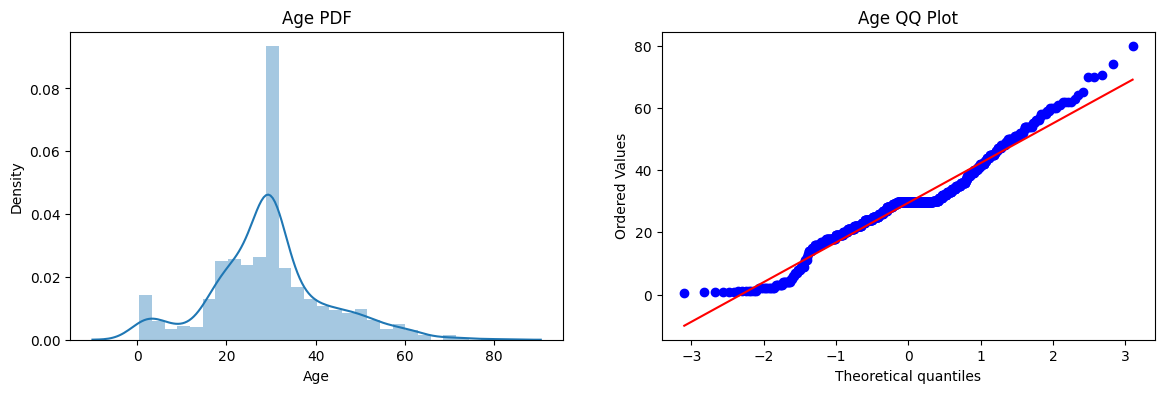

In [19]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'],dist="norm",plot=plt)
plt.title("Age QQ Plot")

plt.show()

/var/folders/3s/ns8l4nq14cq62jr4rlgm2hv80000gn/T/ipykernel_2587/3788811370.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


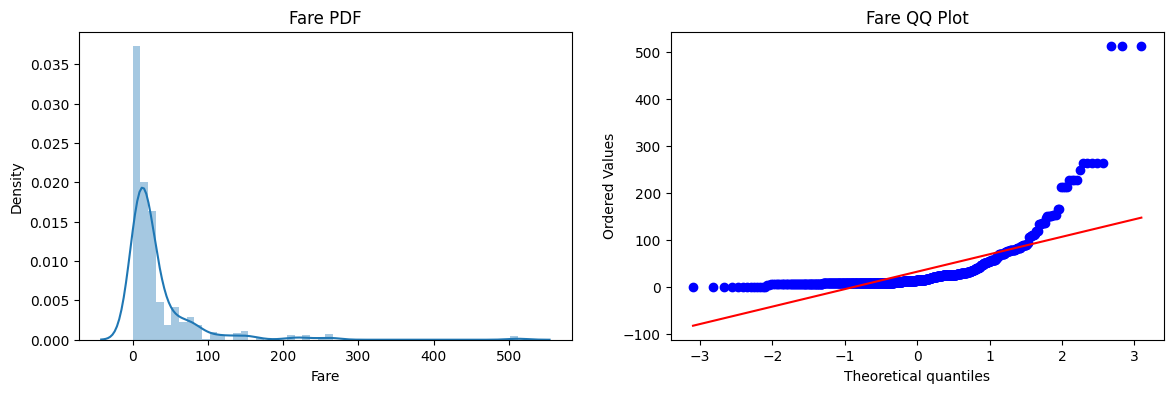

In [26]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title("Fare PDF") # -> right skewed 

plt.subplot(122)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title("Fare QQ Plot")

plt.show()

In [27]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [28]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test)
y_pred2 = clf2.predict(X_test)

print("Accuracy Score : ",accuracy_score(y_test,y_pred))
print("Accuracy Score : ",accuracy_score(y_test,y_pred2))

Accuracy Score :  0.6480446927374302
Accuracy Score :  0.6759776536312849


In [29]:
trf = FunctionTransformer(func=np.log1p)

In [31]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [32]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred = clf.predict(X_test_transformed)
y_predict2 = clf2.predict(X_test_transformed)

print("Accuracy : ",accuracy_score(y_test,y_pred))
print("Accuracy : ",accuracy_score(y_test,y_pred2))

Accuracy :  0.6815642458100558
Accuracy :  0.6759776536312849


In [34]:
# now cross validation 

X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR ",np.mean(cross_val_score(clf,X_transformed,Y,scoring='accuracy',cv=10)))
print("DT ",np.mean(cross_val_score(clf2,X_transformed,Y,scoring='accuracy',cv=10)))

LR  0.678027465667915
DT  0.6622097378277154


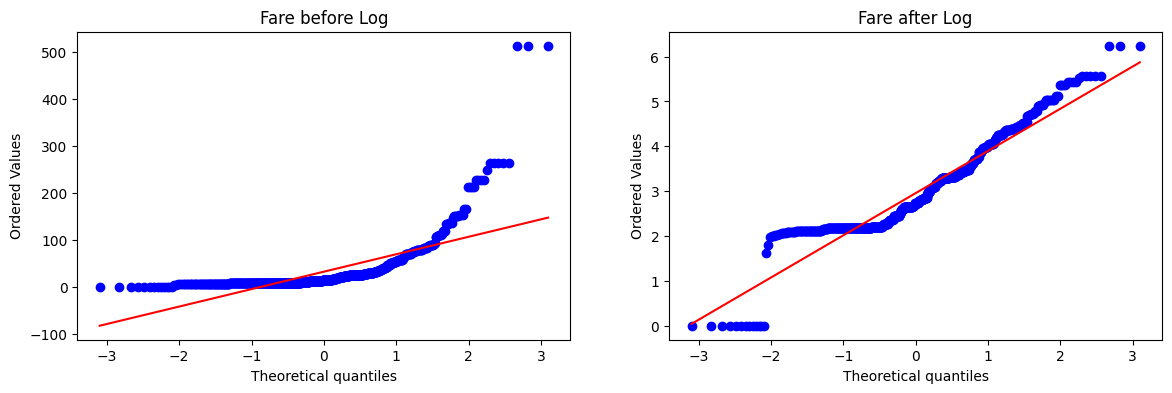

In [39]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title("Fare before Log")

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'],dist='norm',plot=plt)
plt.title("Fare after Log")

plt.show()

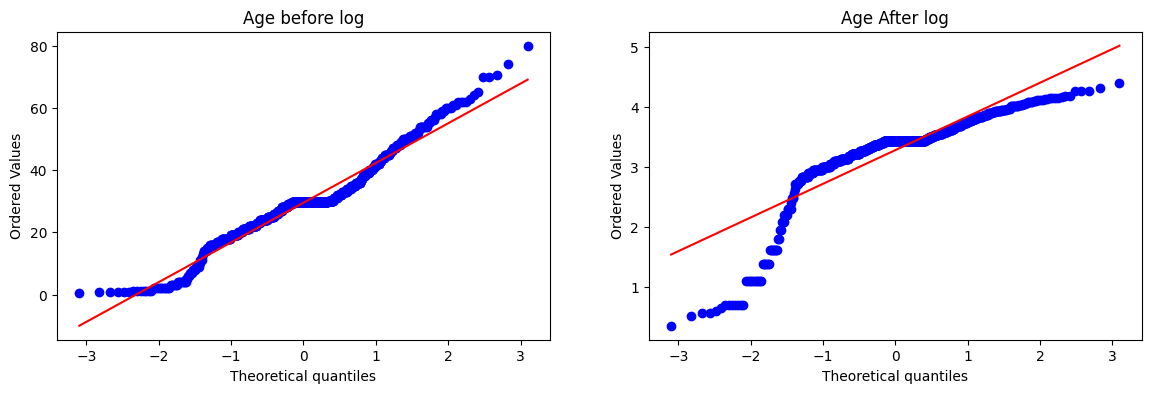

In [41]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title("Age before log")

plt.subplot(122)
stats.probplot(X_train_transformed['Age'],dist='norm',plot=plt)
plt.title("Age After log")
 
plt.show()

In [44]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.fit_transform(X_test)

In [46]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy Score : ",accuracy_score(y_test,y_pred))
print("Accuracy Score : ",accuracy_score(y_test,y_pred2))

Accuracy Score :  0.6703910614525139
Accuracy Score :  0.659217877094972


In [48]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,Y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,Y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6599625468164794


In [57]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    Y = df.iloc[:,0]

    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_tran = trf.fit_transform(X)

    clf = LogisticRegression()

    print("Accueacy : ",np.mean(cross_val_score(clf,X_tran,Y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'],dist='norm',plot=plt)
    plt.title("Fare before transform")

    plt.subplot(122)
    stats.probplot(X_tran[:,0],dist='norm',plot=plt)
    plt.title("Fare after transforma")

    plt.show()

Accueacy :  0.6589013732833957


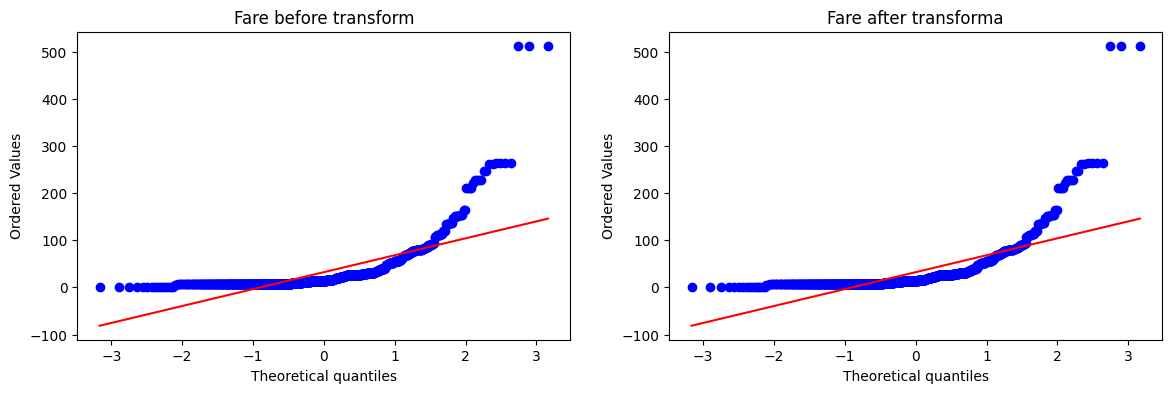

In [58]:
apply_transform(lambda x: x)

Accueacy :  0.6431335830212235


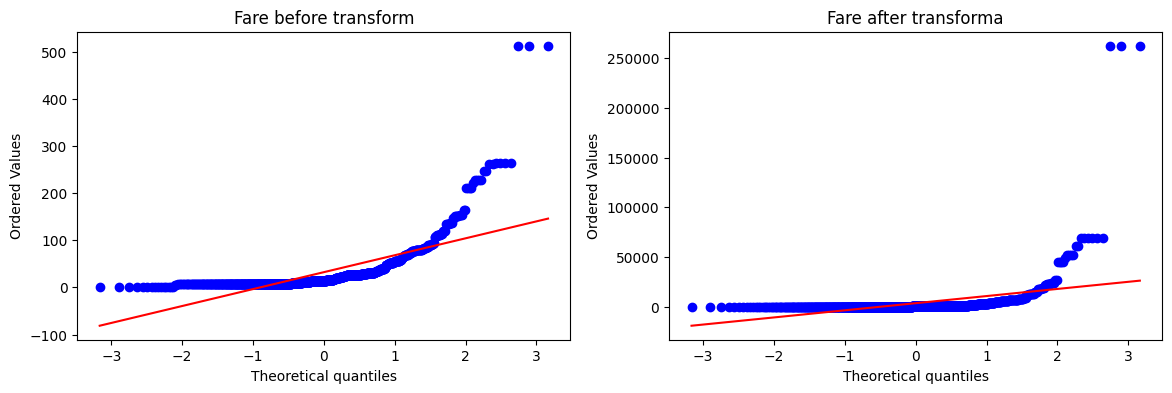

In [60]:
apply_transform(lambda x: x*x)

Accueacy :  0.6195131086142323


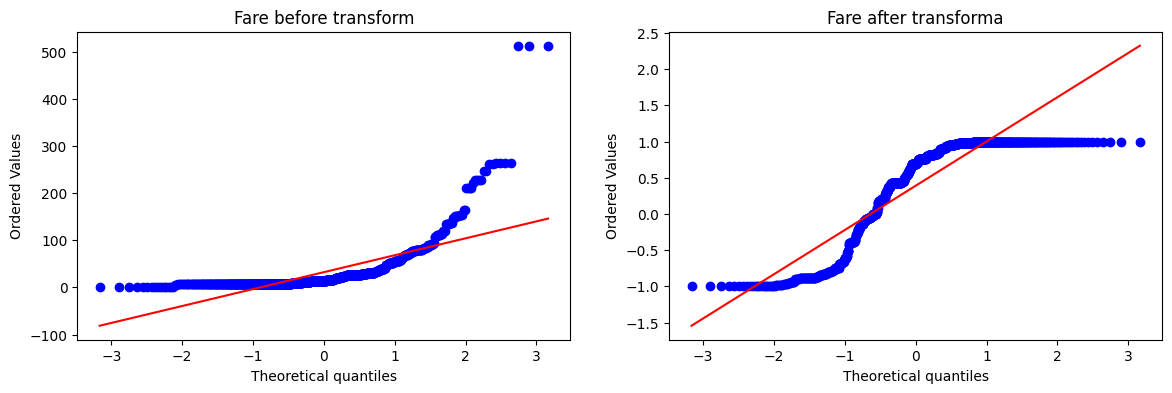

In [61]:
apply_transform(np.sin)

Accueacy :  0.616167290886392


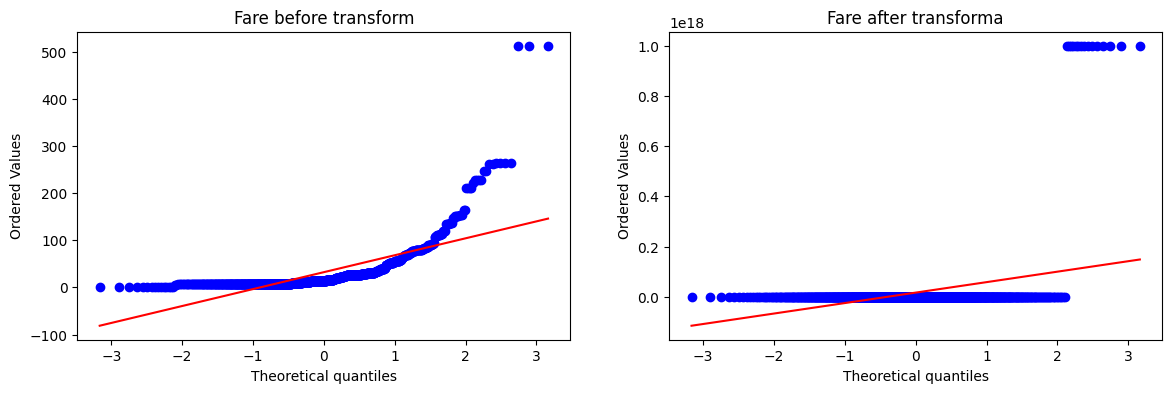

In [63]:
apply_transform(lambda x: 1/(x+0.000000000000000001))